In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)

import matplotlib.pyplot as plt
import random

random.seed(42)

pd.set_option("display.max_columns", None)

- Check if the sku is stock out (if there is 0 for any row, then check whether that shop is selling any other sku or not. )
- Code error: Like some other sku sell has increased randomly, which mean that the current sku code is mixed with any other one. 
- take monthly average for missed data.

In [ ]:
CUSTOMER_LIST = [
    301152,
    304093,
    305104,
    304002,
    302171,
    301182,
    300154,
    308225,
    306140,
    303029,
    306096,
    304025,
    302085,
    302130,
    303088,
    306188,
    309031,
    309110,
    302024,
    302192,
    302153,
    304111,
    305126,
    308135,
    300102,
    300005,
]

In [ ]:
def get_n_random_customers(df, top_5, n=25):

    all_customers = df["customer_code"].dropna().unique()
    random_customers = random.sample(list(all_customers), n)

    random_customers.append(top_5["customer_code"].iloc[0])
    return [int(x) for x in random_customers]

In [ ]:
def wrangle(df, columns, shop_id, sku_id, split_days=7):

    # Convert to date
    df["date"] = pd.to_datetime(df.date)

    # Filter data
    df_filtered = df[(df["customer_code"] == shop_id) & (df["sku_code"] == sku_id)][
        columns
    ].copy()
    df_filtered.sort_values("date", inplace=True)

    # Create full date range
    full_dates = pd.date_range(
        start=df_filtered["date"].min(), end=df_filtered["date"].max(), freq="D"
    )

    df_filtered = df_filtered.groupby("date", as_index=False)["sales_quantity"].sum()

    df_filtered = df_filtered.set_index("date")  # Set index
    df_filtered = df_filtered.reindex(full_dates)  # Reindex
    # df_filtered["sales_quantity"] = df_filtered["sales_quantity"].fillna(0) # Fill missing values with 0
    df_filtered = df_filtered.reset_index()  # Reset index
    df_filtered.rename(columns={"index": "date"}, inplace=True)

    df_prophet = df_filtered.rename(columns={"date": "ds", "sales_quantity": "y"})

    df_prophet = df_prophet[["ds", "y"]]

    # Split data
    split_date = df_prophet["ds"].max() - pd.Timedelta(days=split_days)
    df_train = df_prophet[df_prophet["ds"] <= split_date].copy()
    df_test = df_prophet[df_prophet["ds"] > split_date].copy()

    return df_train, df_test, df_prophet

In [ ]:
def top_n_customers_sku(df, top_n=10):
    top_customers = (
        df.groupby("customer_code")["sales_quantity"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
    )

    top_customer_ids = top_customers.index

    df_top_customers = df[df["customer_code"].isin(top_customer_ids)]

    top_sku_per_customer = (
        df_top_customers.groupby(["customer_code", "sku_code"])["sales_quantity"]
        .sum()
        .reset_index()
        .sort_values(["customer_code", "sales_quantity"], ascending=[True, False])
        .groupby("customer_code")
        .head(1)
    )

    return top_sku_per_customer

In [ ]:
def train_prophet(df_train):
    model = Prophet(
        daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False
    )
    model.fit(df_train)
    return model

In [ ]:
def evaluate(forecast, df_test):

    # Ensure clean merge (no isin)
    eval_df = df_test.merge(forecast[["ds", "yhat"]], on="ds", how="inner")

    # 🚨 remove NaNs safely
    eval_df = eval_df.dropna(subset=["y", "yhat"])

    mae = mean_absolute_error(eval_df["y"], eval_df["yhat"])
    mape = mean_absolute_percentage_error(eval_df["y"], eval_df["yhat"])
    rmse = np.sqrt(mean_squared_error(eval_df["y"], eval_df["yhat"]))

    return {"MAE": mae, "MAPE": mape, "RMSE": rmse}, eval_df

In [ ]:
def plot_results(eval_df, shop_id, sku_id):
    plt.figure(figsize=(12, 6))
    plt.plot(eval_df["ds"], eval_df["y"], label="Actual", marker="o")
    plt.plot(eval_df["ds"], eval_df["yhat"], label="Predicted", marker="x")
    plt.title(f"Actual vs Predicted Sales Quantity for Shop {shop_id} and SKU {sku_id}")
    plt.xlabel("Date")
    plt.ylabel("Sales Quantity")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
df_path = "../../../../data/France/processed_data/sell_out_merged.csv"
df = pd.read_csv(df_path)
df["date"] = pd.to_datetime(df["date"])
df.rename(
    columns={
        "territory_id": "route",
        "territory_name": "route_name",
        "Volume in Unit": "sales_quantity",
        "Volume in Packs": "sales_amount",
    },
    inplace=True,
)

## NOT PART

In [ ]:
# Take customer_list and give top_sku of each
df_filtered_customers = df[df["customer_code"].isin(CUSTOMER_LIST)]

top_sku_per_customer = (
    df_filtered_customers.groupby(["customer_code", "sku_code"])["sales_quantity"]
    .sum()
    .reset_index()
    .sort_values(["customer_code", "sales_quantity"], ascending=[True, False])
    .groupby("customer_code")
    .head(1)
)
top_sku_per_customer.head()

,customer_code,sku_code,sales_quantity
10,300005.0,a0U1t000002PXlqEAG,26060
108,300102.0,a0U1t000002PXlqEAG,9420
180,300154.0,a0U1t000002PXlqEAG,15260
296,301152.0,a0U1t000002PXlqEAG,5180
337,301182.0,a0U1t000002PXloEAG,3740


In [ ]:
import pandas as pd

# ------------------------------
# Step 1: Prepare list of all shop-sku data
# ------------------------------

all_customers_sku_data = []

for shop_id, sku_id in zip(
    top_sku_per_customer["customer_code"], top_sku_per_customer["sku_code"]
):
    df_selected_shop = df[df["customer_code"] == shop_id]
    shop_unique_dates = (
        df_selected_shop["date"].drop_duplicates().sort_values().tolist()
    )

    df_selected_shop_selected_sku = df_selected_shop[
        df_selected_shop["sku_code"] == sku_id
    ]
    shop_sku_unique_dates = (
        df_selected_shop_selected_sku["date"].drop_duplicates().sort_values().tolist()
    )

    # Get category from original df
    category_list = df_selected_shop_selected_sku["category"].unique().tolist()
    category = category_list[0] if len(category_list) > 0 else None

    all_customers_sku_data.append(
        {
            "shop_id": shop_id,
            "sku_id": sku_id,
            "category": category,
            "shop_unique_dates": shop_unique_dates,
            "shop_sku_unique_dates": shop_sku_unique_dates,
        }
    )

# ------------------------------
# Step 2: Convert to DataFrame and initialize columns
# ------------------------------

all_customers_sku_data_df = pd.DataFrame(all_customers_sku_data)

# Initialize columns safely
all_customers_sku_data_df["stockout_dates"] = [
    [] for _ in range(len(all_customers_sku_data_df))
]
all_customers_sku_data_df["stockout_gaps"] = [
    [] for _ in range(len(all_customers_sku_data_df))
]
all_customers_sku_data_df["stockout_days_count"] = 0
all_customers_sku_data_df["total_shop_days"] = 0
all_customers_sku_data_df["sku_active_days"] = 0
all_customers_sku_data_df["stockout_ratio"] = 0.0

# ------------------------------
# Step 3: Calculate stockout info
# ------------------------------

for idx, row in all_customers_sku_data_df.iterrows():
    shop_dates = sorted(set(row["shop_unique_dates"]))
    sku_dates = sorted(set(row["shop_sku_unique_dates"]))
    shop_dates_set = set(shop_dates)

    total_shop_days = len(shop_dates)
    sku_active_days = len(sku_dates)

    stockout_gaps = []
    stockout_dates = []

    # Loop over SKU dates to find gaps
    for i in range(1, len(sku_dates)):
        prev_date = sku_dates[i - 1]
        curr_date = sku_dates[i]

        diff = (curr_date - prev_date).days

        if diff > 1:
            # Create missing range between current SKU dates
            missing_range = pd.date_range(
                start=prev_date + pd.Timedelta(days=1),
                end=curr_date - pd.Timedelta(days=1),
            )

            # Only consider days when shop is open
            valid_stockout_days = [d for d in missing_range if d in shop_dates_set]

            if len(valid_stockout_days) > 0:
                stockout_gaps.append(len(valid_stockout_days))
                stockout_dates.extend(valid_stockout_days)

    stockout_dates = sorted(set(stockout_dates))
    stockout_days_count = len(stockout_dates)
    stockout_ratio = stockout_days_count / total_shop_days if total_shop_days > 0 else 0

    # Store everything
    all_customers_sku_data_df.at[idx, "stockout_dates"] = stockout_dates
    all_customers_sku_data_df.at[idx, "stockout_gaps"] = stockout_gaps
    all_customers_sku_data_df.at[idx, "stockout_days_count"] = stockout_days_count
    all_customers_sku_data_df.at[idx, "total_shop_days"] = total_shop_days
    all_customers_sku_data_df.at[idx, "sku_active_days"] = sku_active_days
    all_customers_sku_data_df.at[idx, "stockout_ratio"] = stockout_ratio

In [ ]:
category_map = df[["customer_code", "sku_code", "category"]].drop_duplicates()

all_customers_sku_data_df = all_customers_sku_data_df.merge(
    category_map,
    left_on=["shop_id", "sku_id"],
    right_on=["customer_code", "sku_code"],
    how="left",
)

all_customers_sku_data_df.drop(["customer_code", "sku_code"], axis=1, inplace=True)
all_customers_sku_data_df.sort_values(
    "stockout_days_count", ascending=False, inplace=True
)

In [ ]:
all_customers_sku_data_df.to_csv(
    "../../../../data/France/derived/top_customers_sku_stockout_analysis.csv",
    index=False,
)

In [ ]:
all_customers_sku_data_df[all_customers_sku_data_df["shop_id"] == 305104][
    "shop_unique_dates"
].tolist()

[[Timestamp('2026-01-01 00:00:00'),
  Timestamp('2026-01-02 00:00:00'),
  Timestamp('2026-01-03 00:00:00'),
  Timestamp('2026-01-04 00:00:00'),
  Timestamp('2026-01-05 00:00:00'),
  Timestamp('2026-01-06 00:00:00'),
  Timestamp('2026-01-07 00:00:00'),
  Timestamp('2026-01-08 00:00:00'),
  Timestamp('2026-01-09 00:00:00'),
  Timestamp('2026-01-10 00:00:00'),
  Timestamp('2026-01-11 00:00:00'),
  Timestamp('2026-01-12 00:00:00'),
  Timestamp('2026-01-13 00:00:00'),
  Timestamp('2026-01-14 00:00:00'),
  Timestamp('2026-01-15 00:00:00'),
  Timestamp('2026-01-16 00:00:00'),
  Timestamp('2026-01-17 00:00:00'),
  Timestamp('2026-01-18 00:00:00'),
  Timestamp('2026-01-19 00:00:00'),
  Timestamp('2026-01-25 00:00:00'),
  Timestamp('2026-01-26 00:00:00'),
  Timestamp('2026-01-27 00:00:00'),
  Timestamp('2026-01-28 00:00:00'),
  Timestamp('2026-01-29 00:00:00'),
  Timestamp('2026-01-30 00:00:00'),
  Timestamp('2026-01-31 00:00:00'),
  Timestamp('2026-02-01 00:00:00'),
  Timestamp('2026-02-02 00:0

In [ ]:
all_customers_sku_data_df[all_customers_sku_data_df["shop_id"] == 305104][
    "shop_sku_unique_dates"
].tolist()

[[Timestamp('2026-01-01 00:00:00'),
  Timestamp('2026-01-02 00:00:00'),
  Timestamp('2026-01-03 00:00:00'),
  Timestamp('2026-01-04 00:00:00'),
  Timestamp('2026-01-05 00:00:00'),
  Timestamp('2026-01-06 00:00:00'),
  Timestamp('2026-01-07 00:00:00'),
  Timestamp('2026-01-08 00:00:00'),
  Timestamp('2026-01-09 00:00:00'),
  Timestamp('2026-01-10 00:00:00'),
  Timestamp('2026-01-11 00:00:00'),
  Timestamp('2026-01-12 00:00:00'),
  Timestamp('2026-01-13 00:00:00'),
  Timestamp('2026-01-14 00:00:00'),
  Timestamp('2026-01-15 00:00:00'),
  Timestamp('2026-01-16 00:00:00'),
  Timestamp('2026-01-17 00:00:00'),
  Timestamp('2026-01-18 00:00:00'),
  Timestamp('2026-01-19 00:00:00'),
  Timestamp('2026-01-25 00:00:00'),
  Timestamp('2026-01-26 00:00:00'),
  Timestamp('2026-01-27 00:00:00'),
  Timestamp('2026-01-28 00:00:00'),
  Timestamp('2026-01-29 00:00:00'),
  Timestamp('2026-01-30 00:00:00'),
  Timestamp('2026-01-31 00:00:00'),
  Timestamp('2026-02-10 00:00:00'),
  Timestamp('2026-02-11 00:0

## Extra Analysis

In [282]:
df.head(2)

,date,customer_code,customer_name,latitude,longitude,route,route_name,channel_name,brand_name,category,sku_code,sales_quantity,sales_amount
0,2026-02-01,576579.0,576579 - TABAC,48.86806,2.35239,a0D1t000005iLAGEA2,France_FRDiv_Reg1_AREA_A_SECTEUR_A_01,Independent,FR_BF_,Vapour Devices,a0UJz000007USXVMA4,1,1
1,2026-02-01,576579.0,576579 - TABAC,48.86806,2.35239,a0D1t000005iLAGEA2,France_FRDiv_Reg1_AREA_A_SECTEUR_A_01,Independent,FR_BF_,Vapour Liquids,a0UJz000009CfTdMAK,1,1


In [287]:
df.groupby("category").agg(
    total_sales=("sales_quantity", "sum"),
    average_sales=("sales_quantity", "mean"),
    max_sales=("sales_quantity", "max"),
    min_sales=("sales_quantity", "min"),
    p25=("sales_quantity", lambda x: x.quantile(0.25)),
    median=("sales_quantity", lambda x: x.quantile(0.5)),
    p75=("sales_quantity", lambda x: x.quantile(0.75)),
)

,total_sales,average_sales,max_sales,min_sales,p25,median,p75
category,,,,,,,
FMC,31378095,72.928896,6000,-800,20.0,40.0,80.0
MYO,17670,41.478873,450,0,30.0,30.0,30.0
Oral,243660,9.599338,1000,-460,1.0,2.0,5.0
RYO,1093710,41.461390,960,-150,30.0,30.0,50.0
Vapour Devices,19321,1.318210,46,-31,1.0,1.0,1.0
Vapour Liquids,91136,1.773074,56,-150,1.0,1.0,2.0


In [ ]:
df[df.sku_code.isna()]["sales_quantity"].sum()

185367751

In [10]:
# Get all customer in CUSTOMER_LIST data
df_filtered_customers = df[df["customer_code"].isin(CUSTOMER_LIST)]

In [ ]:
df_filtered_customers["category"].unique()

array(['Oral', 'Vapour Liquids', 'Vapour Devices', nan, 'FMC', 'RYO',
       'MYO'], dtype=object)

In [30]:
top_sku_per_customer = top_n_customers_sku(df_filtered_customers, top_n=5)

12:41:27 - cmdstanpy - INFO - Chain [1] start processing


Processing Customer 300005 and SKU a0U1t000002PXlqEAG...


12:41:27 - cmdstanpy - INFO - Chain [1] done processing


Results for Customer 300005 and SKU a0U1t000002PXlqEAG: {'MAE': 212.6000688710779, 'MAPE': 0.7162323846523104, 'RMSE': 237.66221273572114}


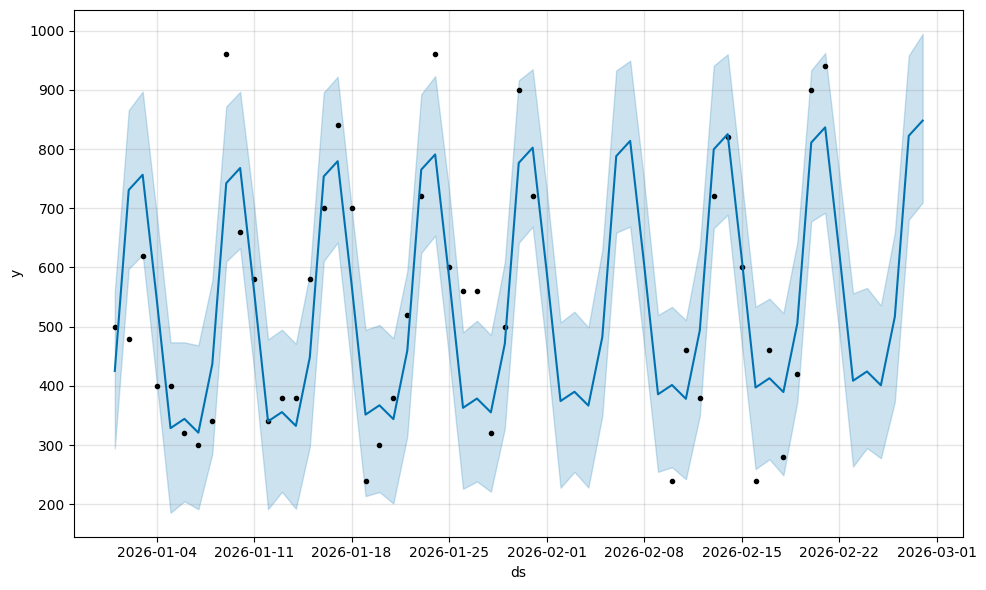

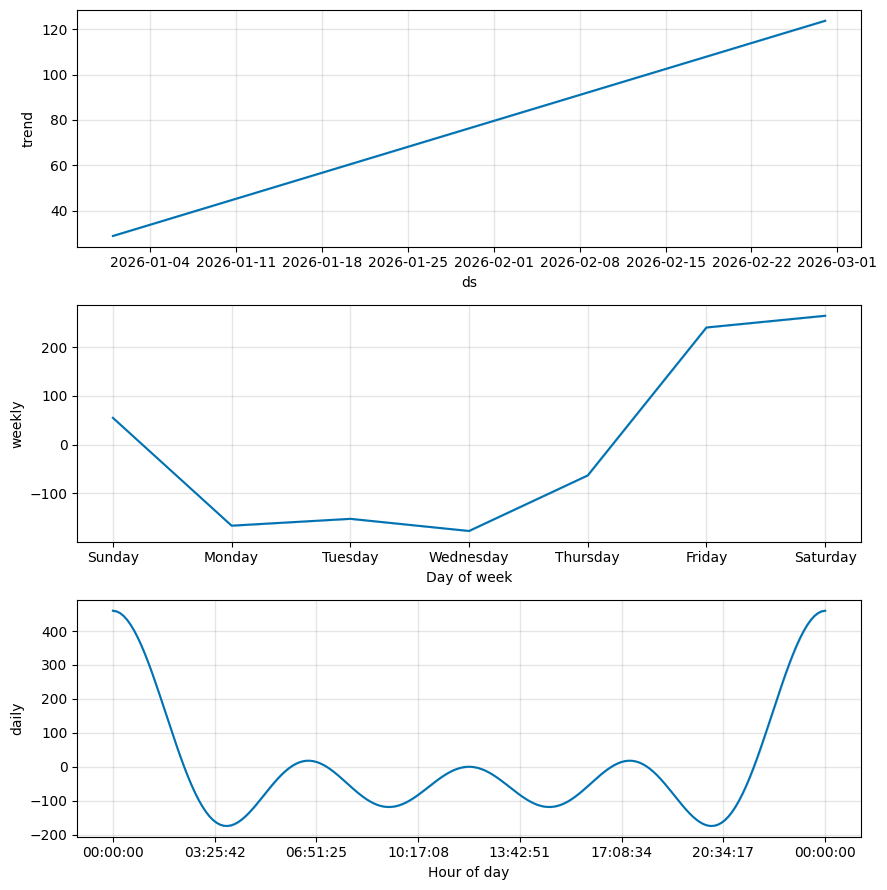

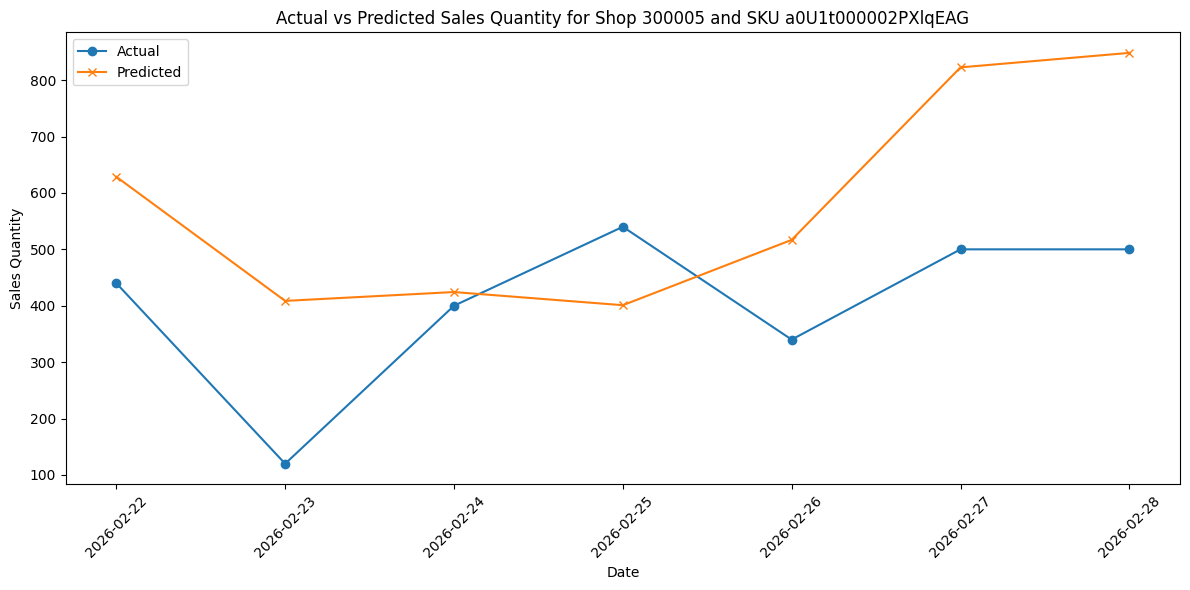

12:41:28 - cmdstanpy - INFO - Chain [1] start processing


Processing Customer 302153 and SKU a0U1t000002PXlqEAG...


12:41:28 - cmdstanpy - INFO - Chain [1] done processing


Results for Customer 302153 and SKU a0U1t000002PXlqEAG: {'MAE': 161.76359871526302, 'MAPE': 0.2921328451893874, 'RMSE': 203.73952129932437}


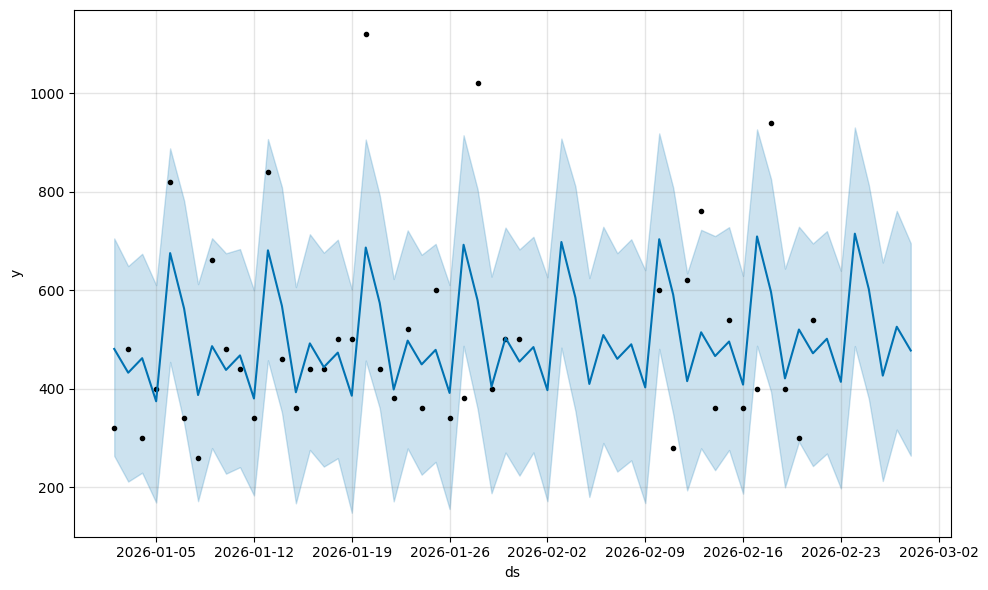

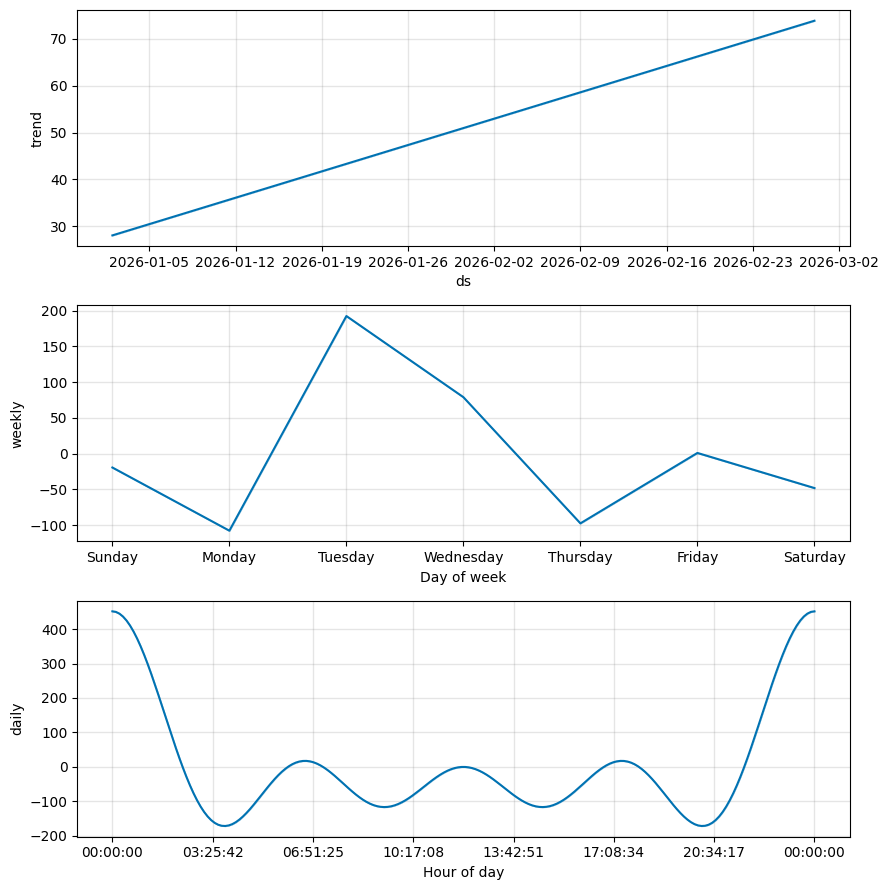

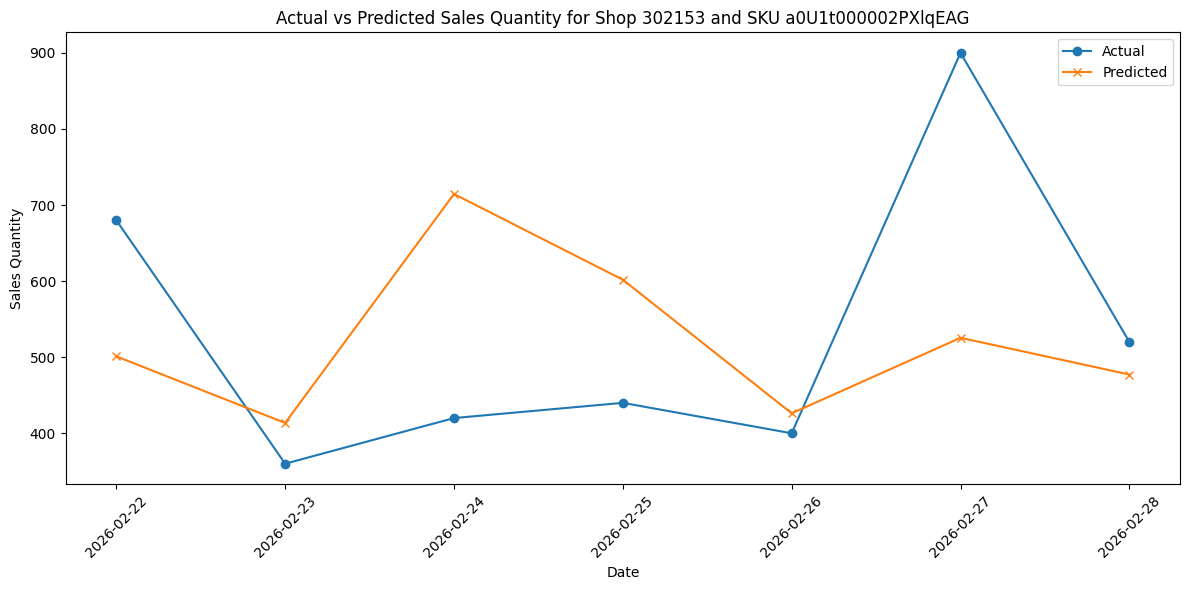

12:41:30 - cmdstanpy - INFO - Chain [1] start processing


Processing Customer 304025 and SKU a0U1t000002PXloEAG...


12:41:30 - cmdstanpy - INFO - Chain [1] done processing


Results for Customer 304025 and SKU a0U1t000002PXloEAG: {'MAE': 50.04390524925114, 'MAPE': 1.4481204467862134, 'RMSE': 63.48834469245828}


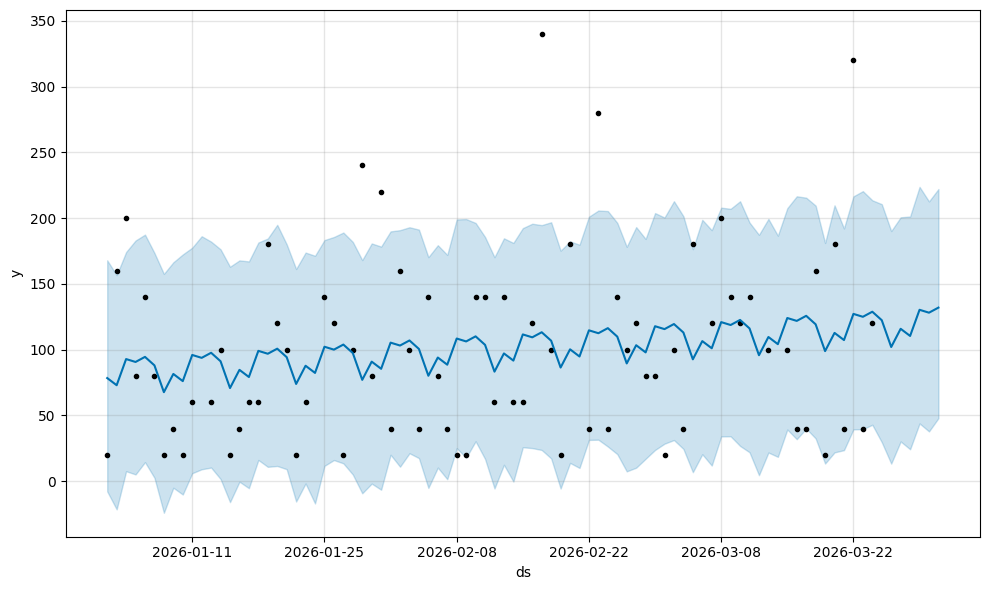

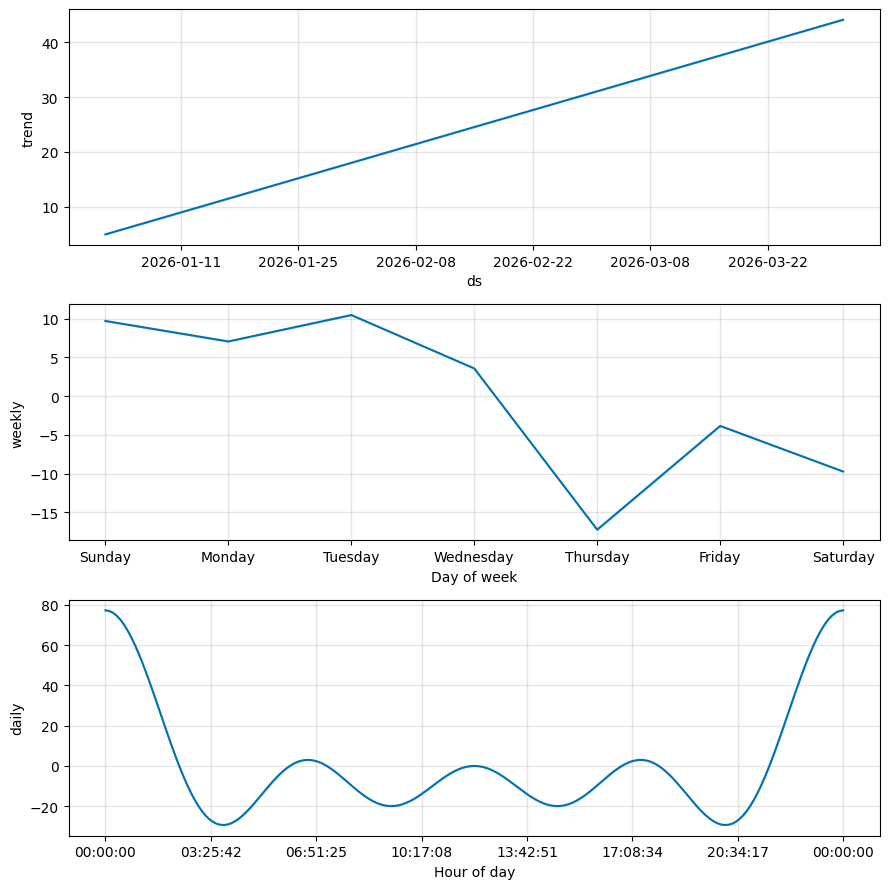

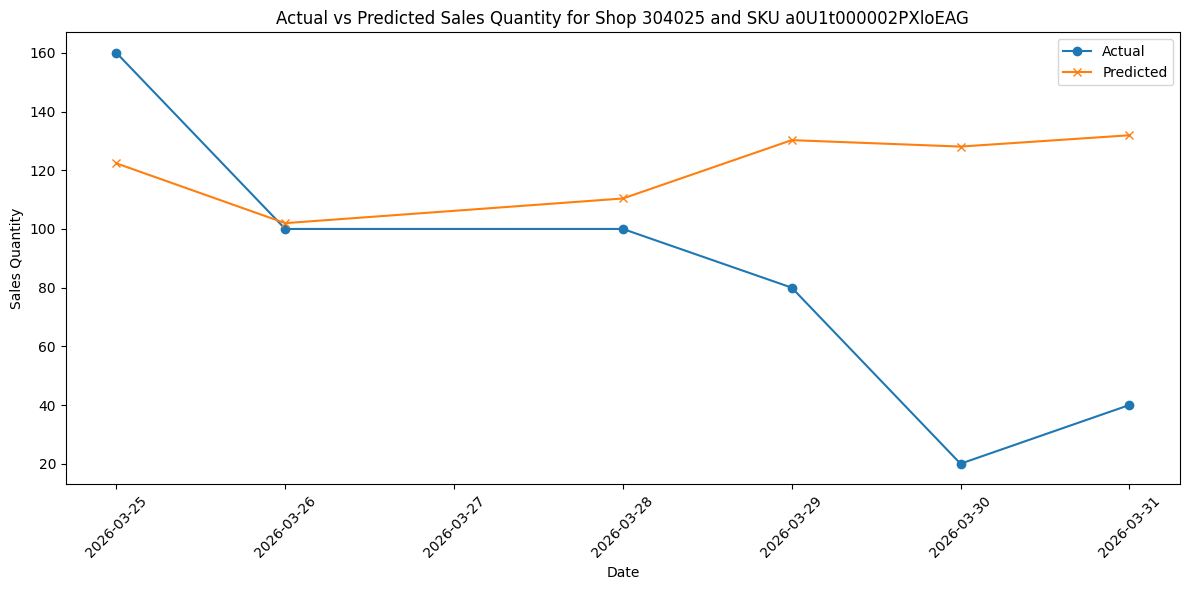

Processing Customer 304093 and SKU a0U1t000002PXlqEAG...


12:41:31 - cmdstanpy - INFO - Chain [1] start processing
12:41:32 - cmdstanpy - INFO - Chain [1] done processing


Results for Customer 304093 and SKU a0U1t000002PXlqEAG: {'MAE': 62.607250207138904, 'MAPE': 0.7933611848988501, 'RMSE': 68.97943377060366}


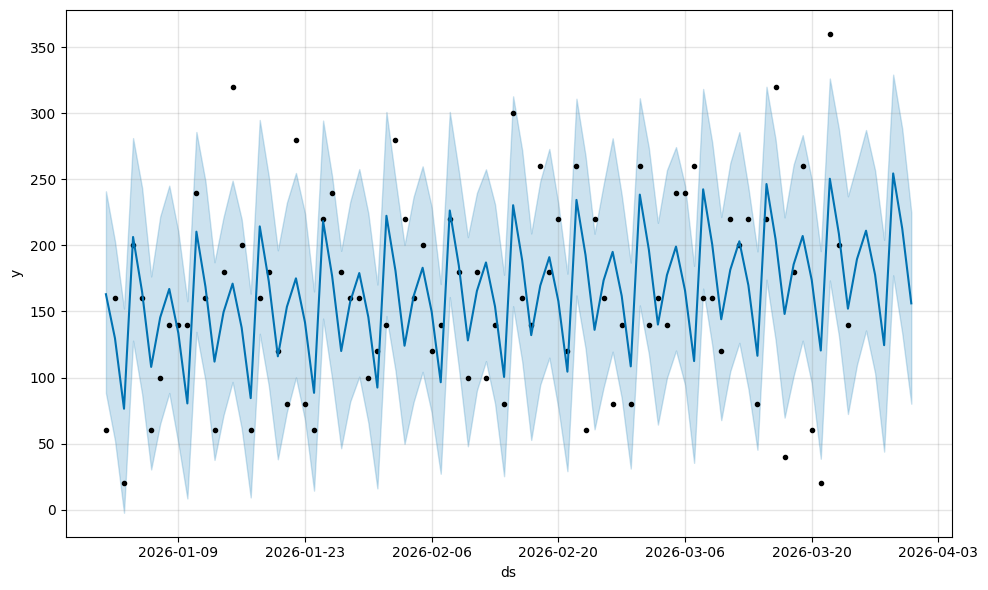

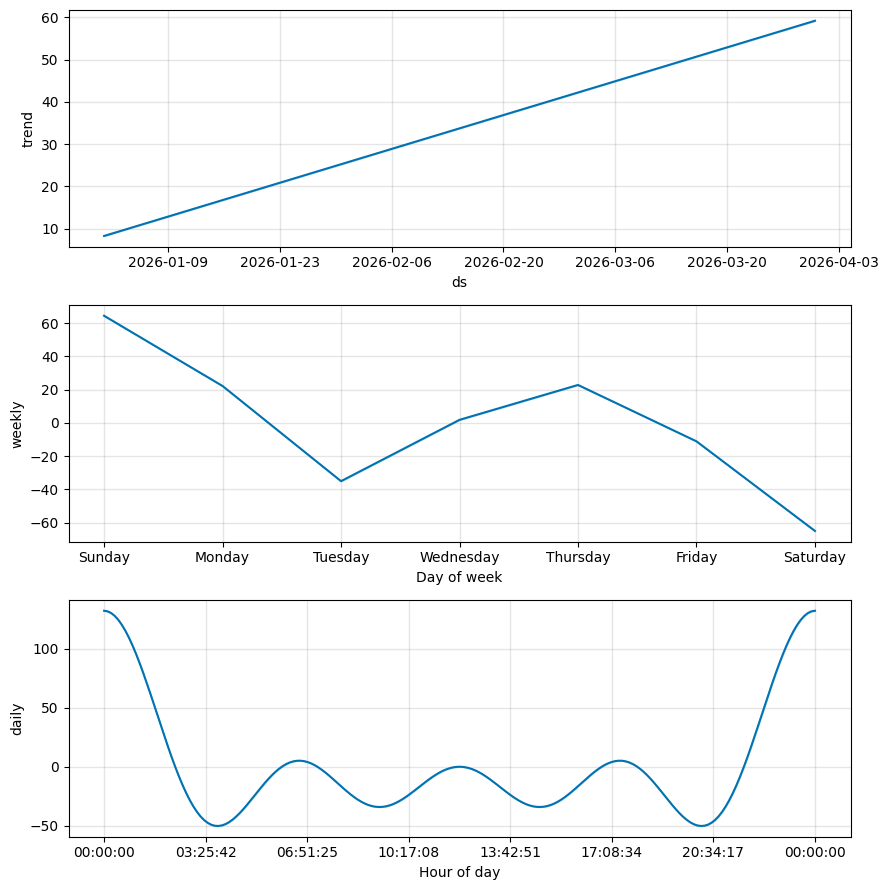

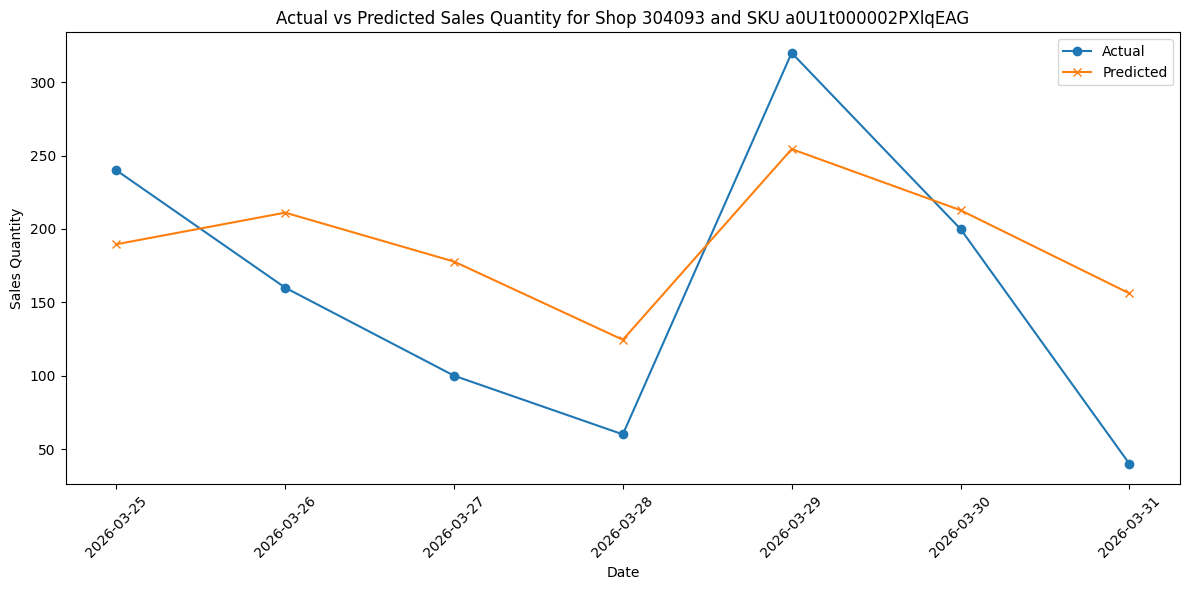

12:41:33 - cmdstanpy - INFO - Chain [1] start processing


Processing Customer 309031 and SKU a0U3W000002BYaXUAW...


12:41:34 - cmdstanpy - INFO - Chain [1] done processing


Results for Customer 309031 and SKU a0U3W000002BYaXUAW: {'MAE': 111.44294652229269, 'MAPE': 0.5189562999877093, 'RMSE': 146.3656271458429}


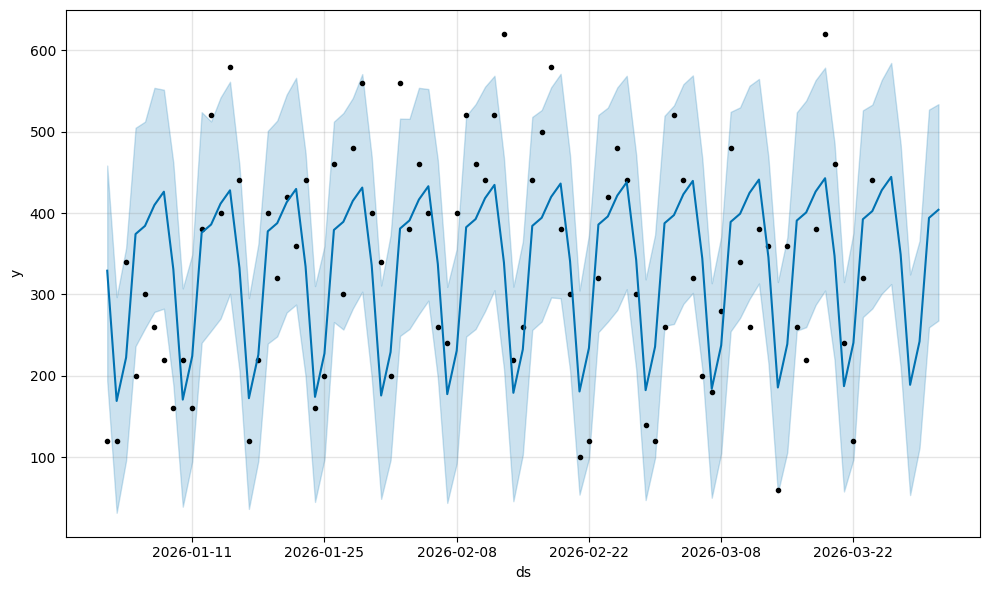

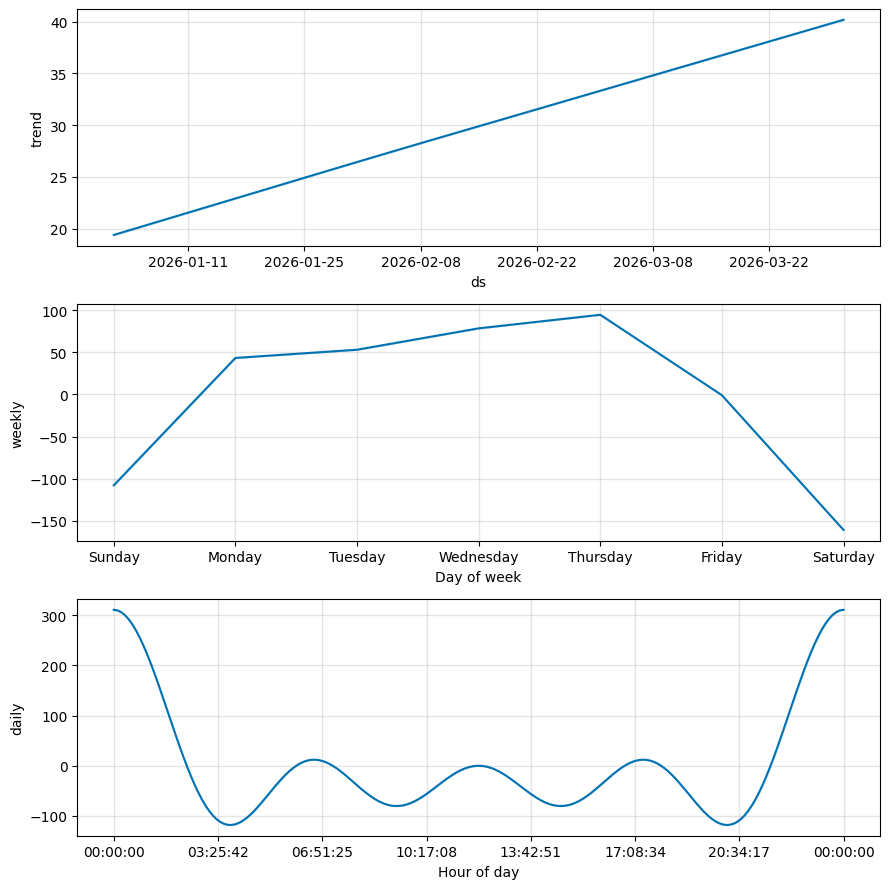

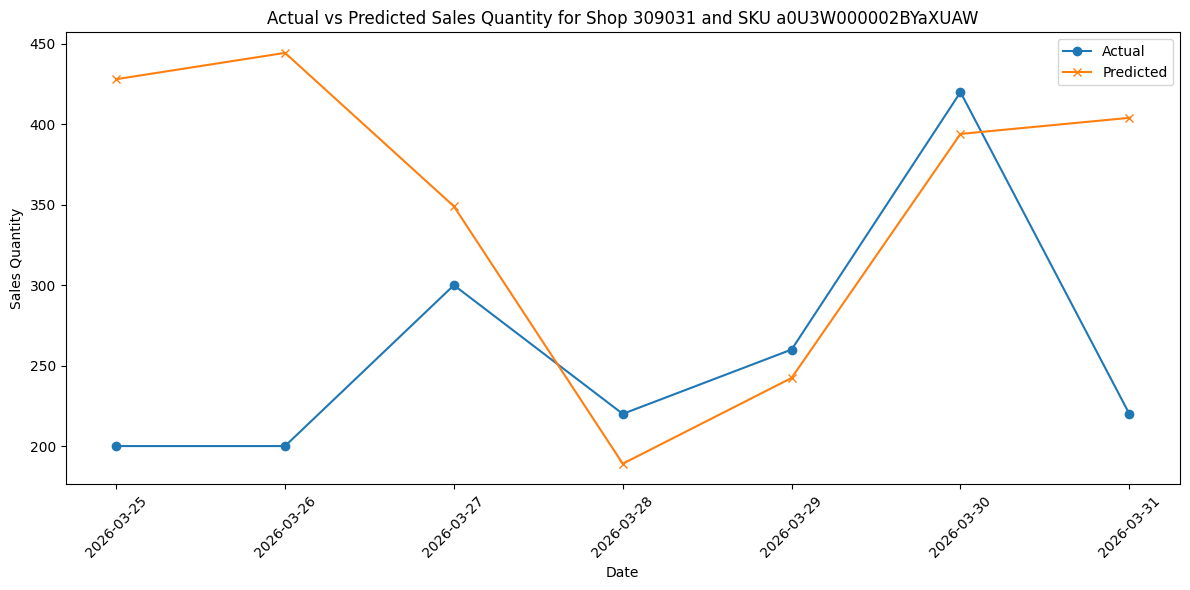

In [ ]:
for index, row in top_sku_per_customer.iterrows():
    shop_id = int(row["customer_code"])
    sku_id = row["sku_code"]

    print(f"Processing Customer {shop_id} and SKU {sku_id}...")

    df_train, df_test, df_prophet = wrangle(
        df, ["date", "customer_code", "sku_code", "sales_quantity"], shop_id, sku_id
    )

    model = train_prophet(df_train)

    future = model.make_future_dataframe(periods=len(df_test))
    forecast = model.predict(future)

    results, eval_df = evaluate(forecast, df_test)
    print(f"Results for Customer {shop_id} and SKU {sku_id}: {results}")
    model.plot(forecast)
    model.plot_components(forecast)
    plot_results(eval_df, shop_id, sku_id)